# **Enhancing Phishing Detection: A Machine Learning Approach With Feature Selection and Deep Learning Models**

# * Import Necessary Libraries.*

In [17]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

### Load Dataset

In [3]:
df =pd.read_csv('dataset_B_05_2020 (1).csv')

In [4]:
df.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


# **Exploratory Data Analysis (EDA)**

In [5]:
df.shape

(11430, 89)

In [6]:
df.describe()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
count,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.0,11430.000000,...,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,1.143000e+04,11430.000000,11430.000000,11430.000000
mean,61.126684,21.090289,0.150569,2.480752,0.997550,0.022222,0.141207,0.162292,0.0,0.293176,...,0.124759,0.775853,0.439545,0.072878,492.532196,4062.543745,8.567566e+05,0.020122,0.533946,3.185739
std,55.297318,10.777171,0.357644,1.369686,2.087087,0.155500,0.364456,0.821337,0.0,0.998317,...,0.330460,0.417038,0.496353,0.259948,814.769415,3107.784600,1.995606e+06,0.140425,0.498868,2.536955
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,-1.000000,-12.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,33.000000,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,84.000000,972.250000,0.000000e+00,0.000000,0.000000,1.000000
50%,47.000000,19.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,242.000000,3993.000000,1.651000e+03,0.000000,1.000000,3.000000
75%,71.000000,24.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,1.000000,0.000000,449.000000,7026.750000,3.738455e+05,0.000000,1.000000,5.000000
max,1641.000000,214.000000,1.000000,24.000000,43.000000,4.000000,3.000000,19.000000,0.0,19.000000,...,1.000000,1.000000,1.000000,1.000000,29829.000000,12874.000000,1.076799e+07,1.000000,1.000000,10.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  114

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  114

In [9]:
df.isnull().sum()

url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64

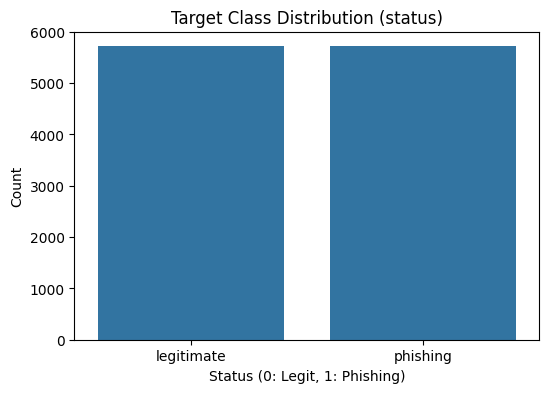

In [10]:
# Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x='status', data=df)
plt.title('Target Class Distribution (status)')
plt.xlabel('Status (0: Legit, 1: Phishing)')
plt.ylabel('Count')
plt.show()



In [11]:
if 'url' in df.columns:
    df.drop('url', axis=1, inplace=True)

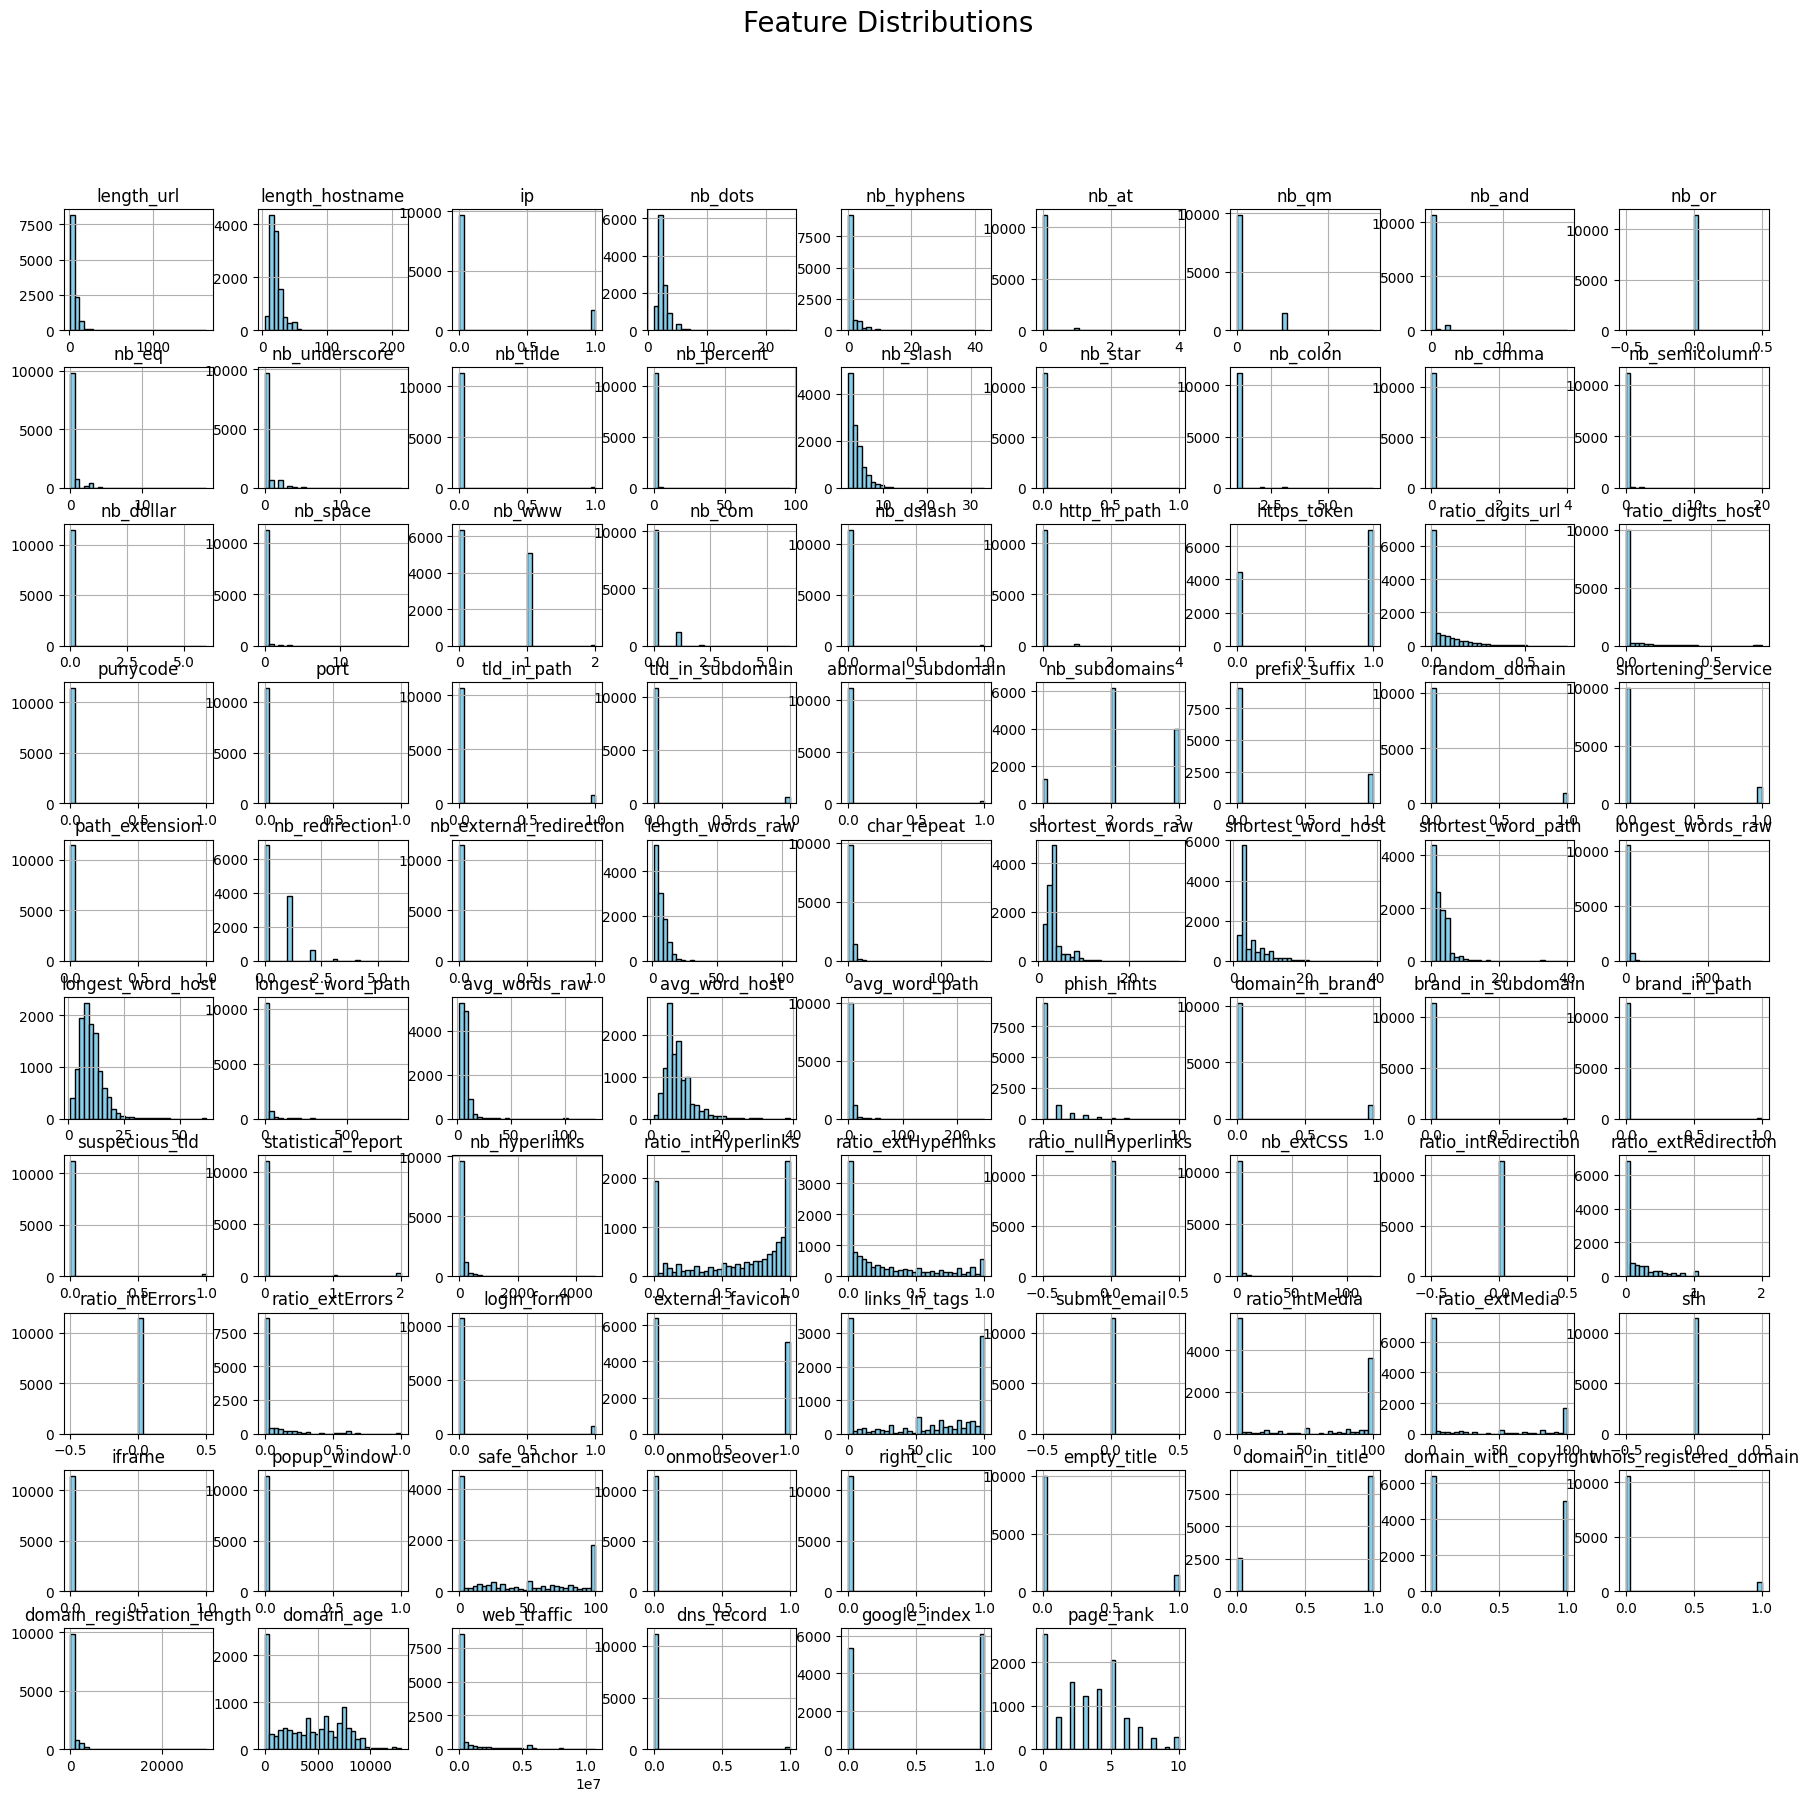

In [12]:
# Plot histograms for all numeric features
df.hist(bins=30, figsize=(22,20), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=20)
plt.show()

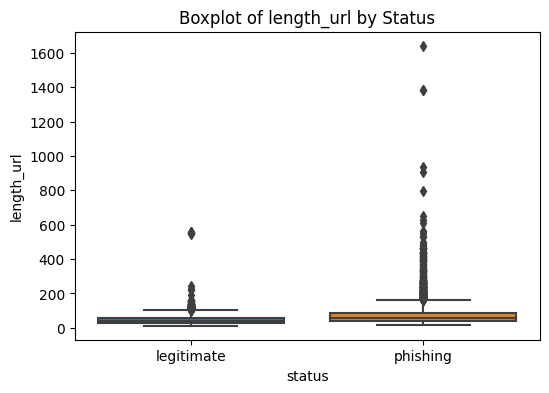

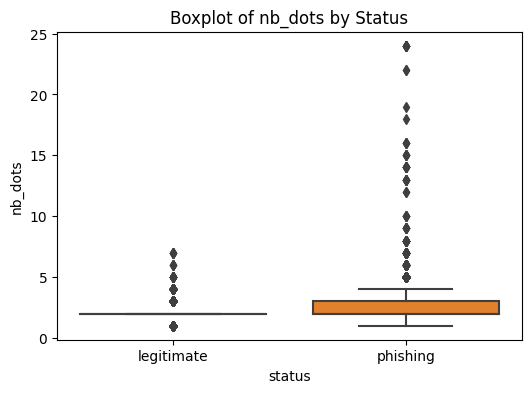

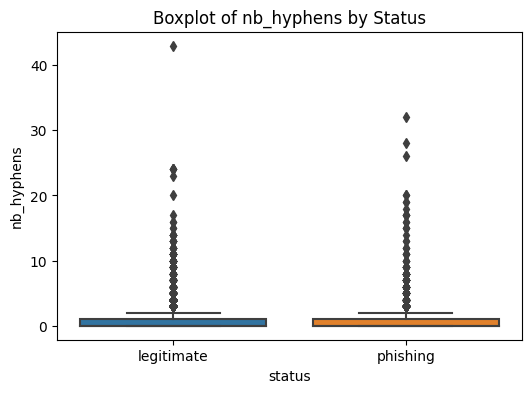

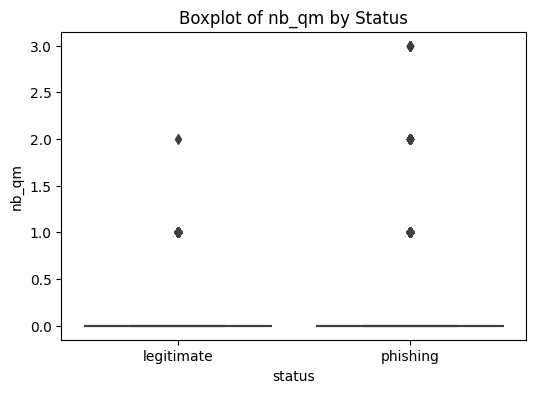

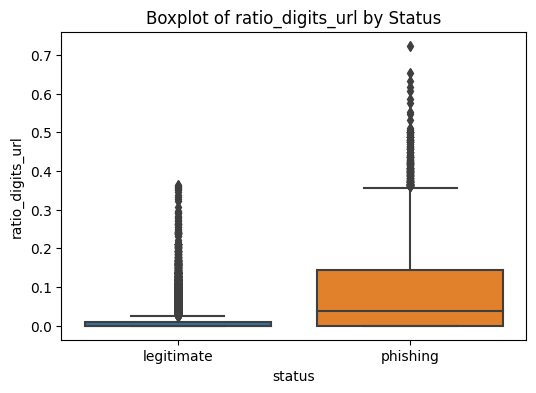

In [13]:
#  Box plots to detect outliers (selected few columns for visibility)
cols_to_plot = ['length_url', 'nb_dots', 'nb_hyphens', 'nb_qm', 'ratio_digits_url']
for col in cols_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='status', y=col, data=df)
    plt.title(f'Boxplot of {col} by Status')
    plt.show()



/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

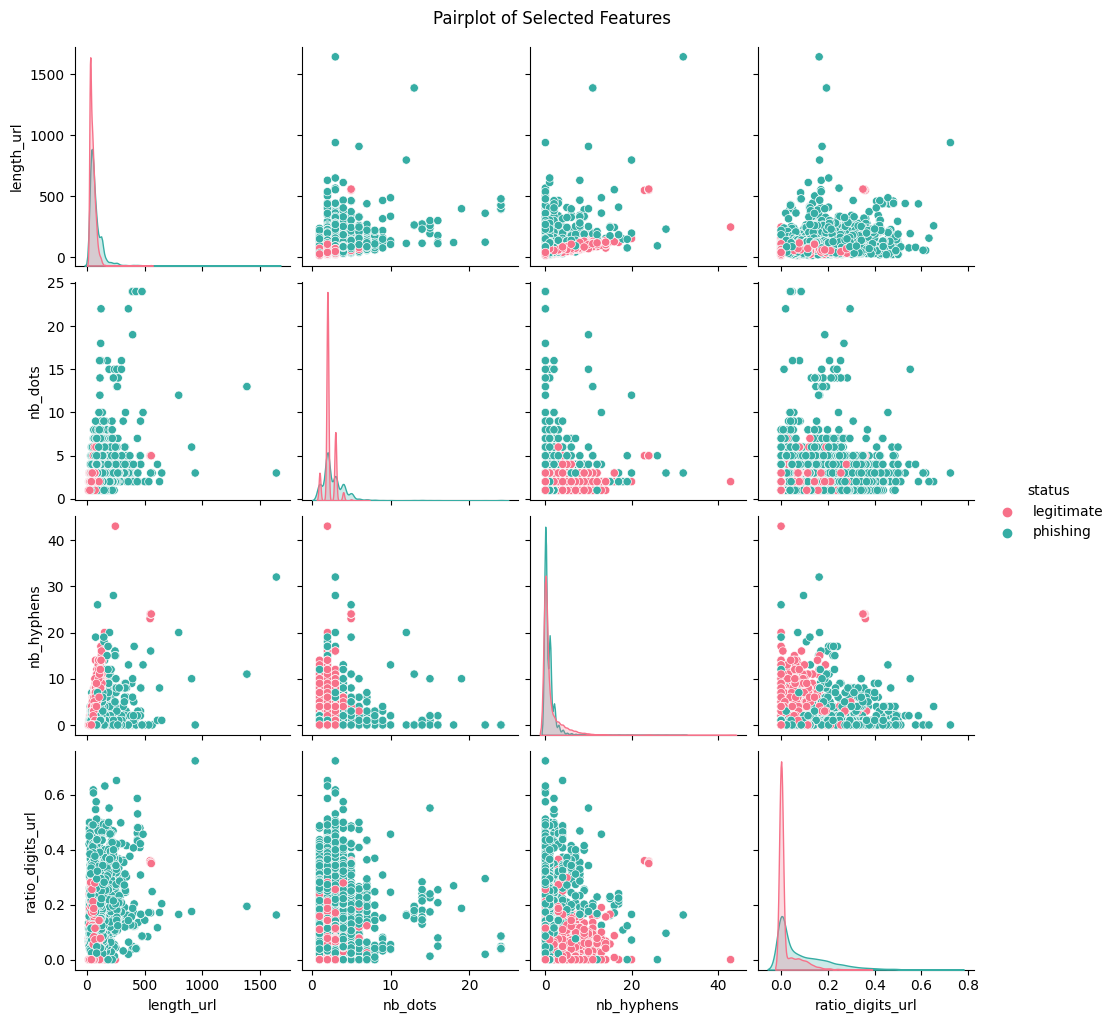

In [14]:
#  Pairplot for selected features
selected_features = ['length_url', 'nb_dots', 'nb_hyphens', 'ratio_digits_url', 'status']
sns.pairplot(df[selected_features], hue='status', palette='husl')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

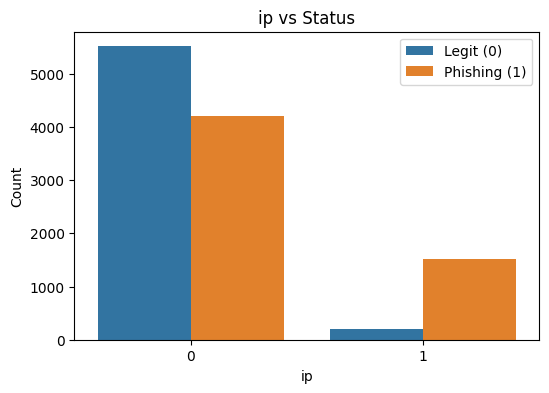

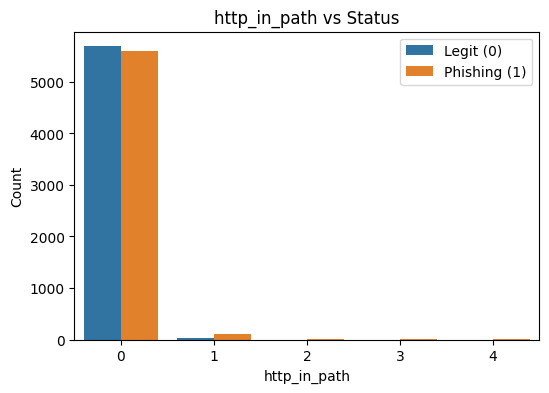

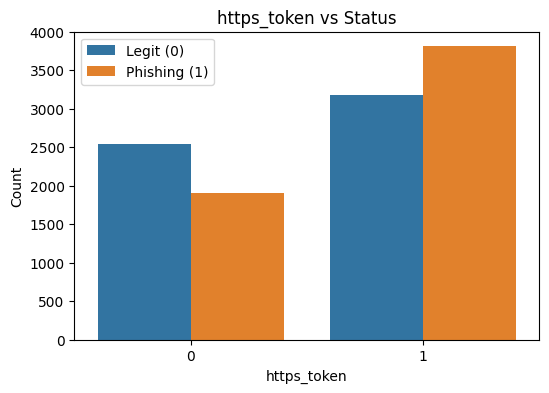

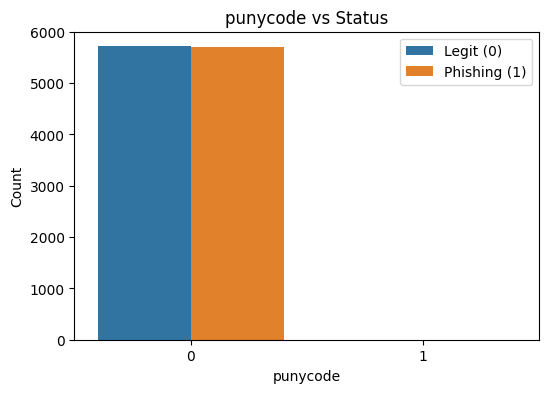

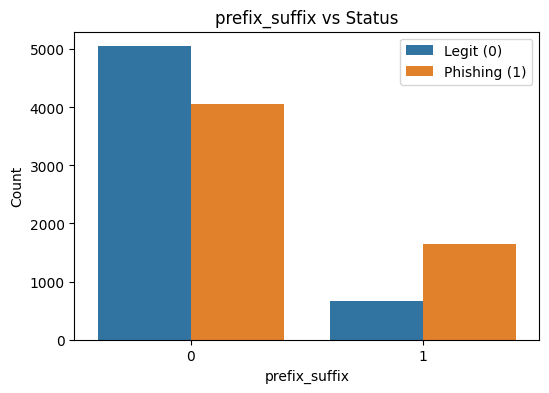

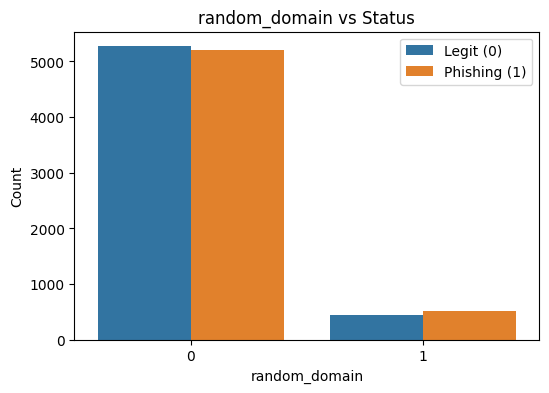

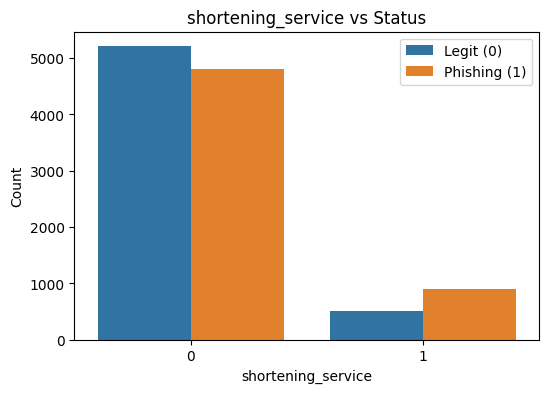

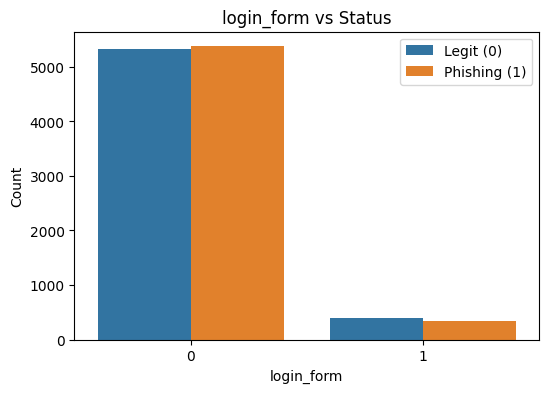

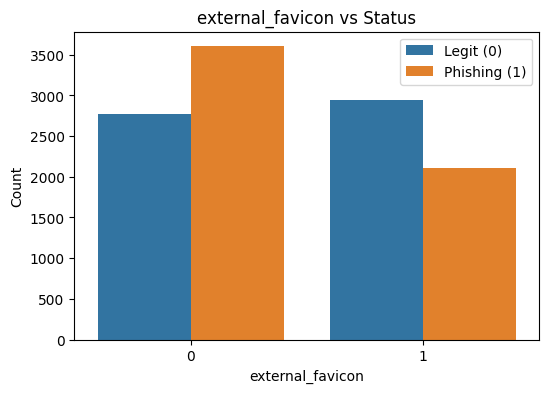

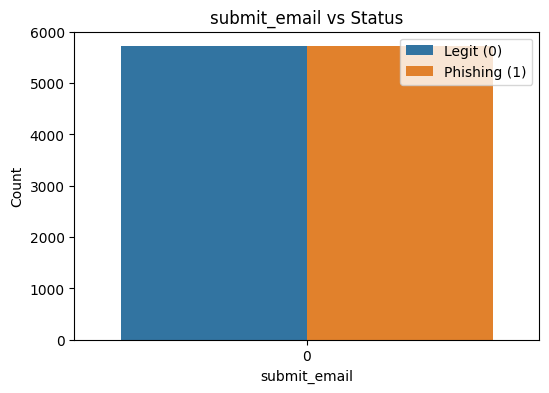

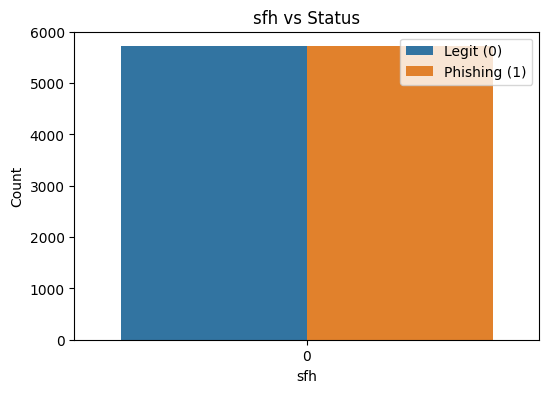

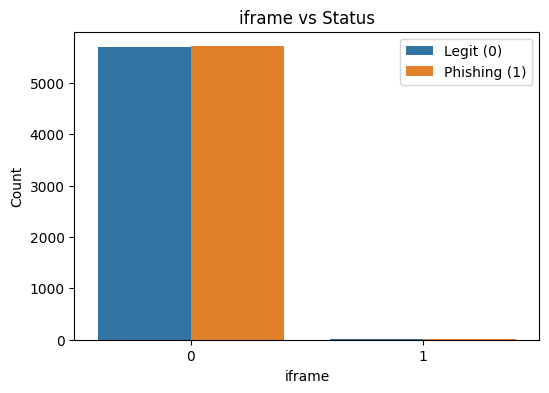

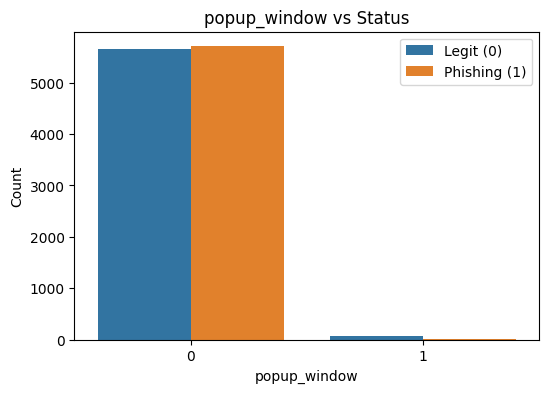

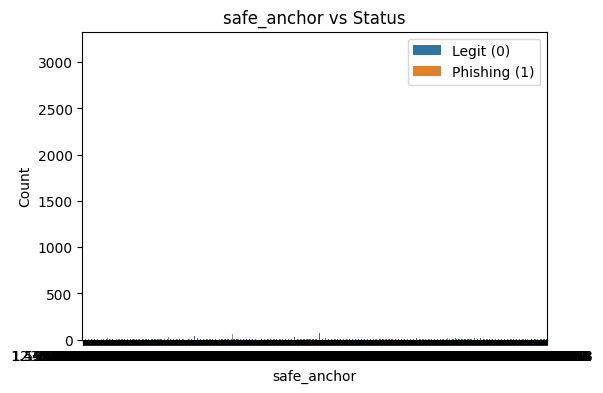

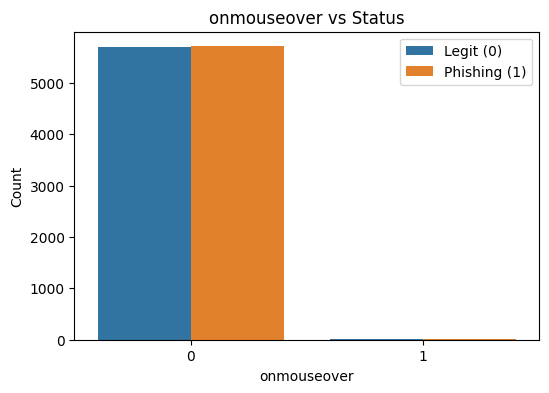

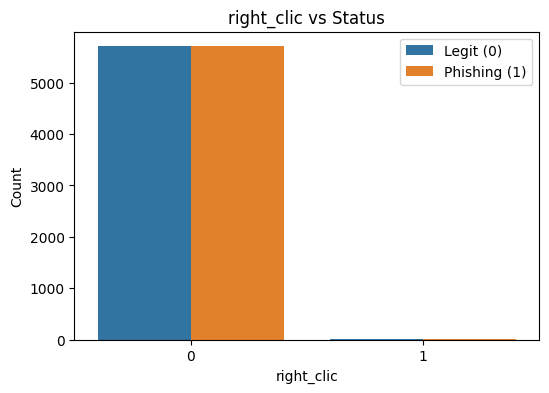

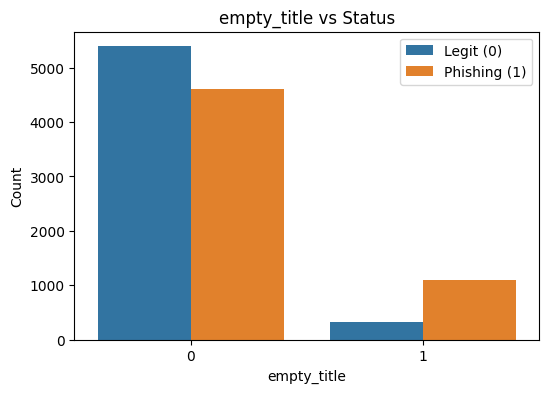

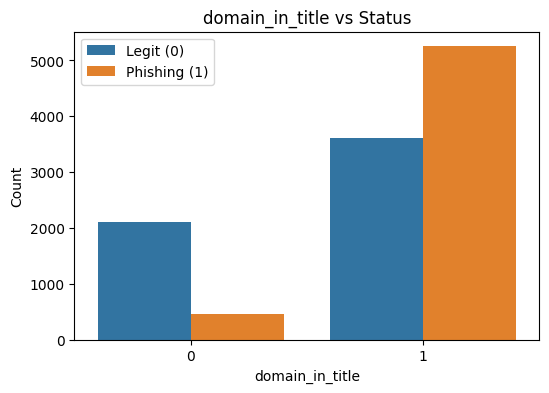

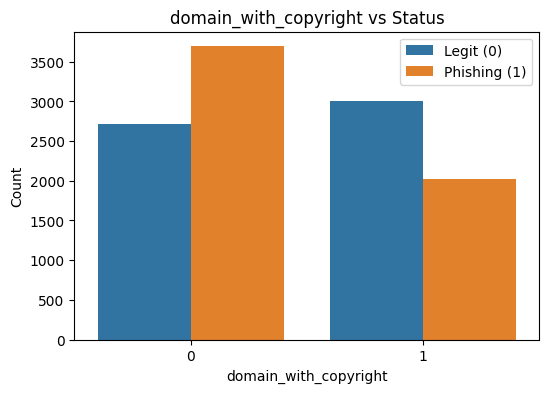

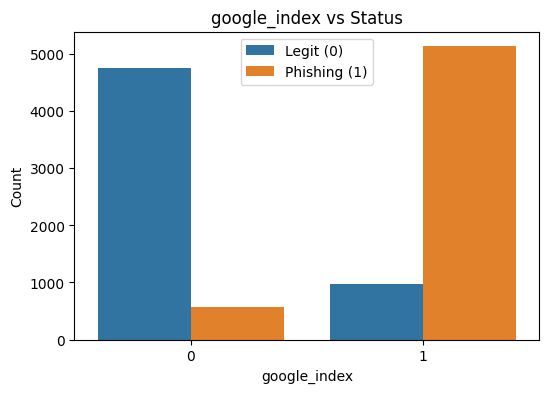

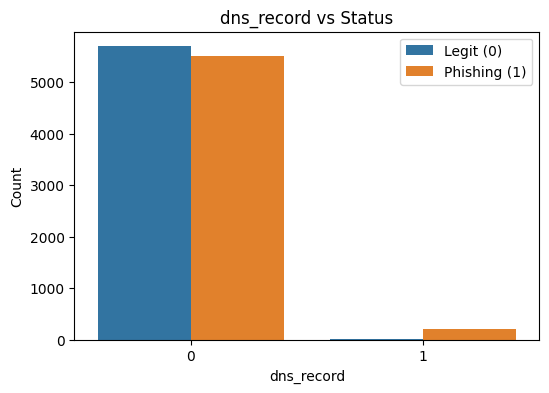

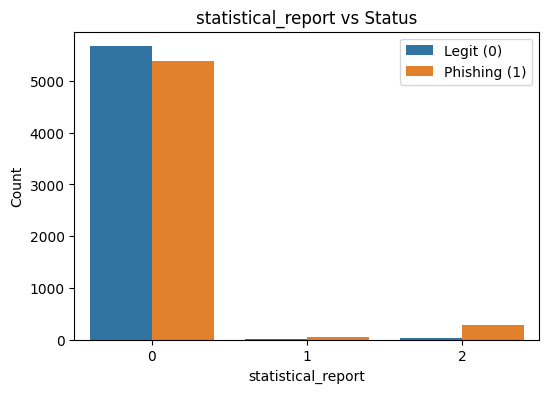

In [15]:
# Count plots for boolean/binary features
binary_features = ['ip', 'http_in_path', 'https_token', 'punycode', 'prefix_suffix', 
                   'random_domain', 'shortening_service', 'login_form', 'external_favicon', 
                   'submit_email', 'sfh', 'iframe', 'popup_window', 'safe_anchor', 
                   'onmouseover', 'right_clic', 'empty_title', 'domain_in_title', 
                   'domain_with_copyright', 'google_index', 'dns_record', 'statistical_report']

for col in binary_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='status', data=df)
    plt.title(f'{col} vs Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(['Legit (0)', 'Phishing (1)'])
    plt.show()


In [12]:

# Separate numerical and non-numerical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
non_numeric_cols = df.select_dtypes(exclude=['int64', 'float64']).columns

print("Numeric Columns:", list(numeric_cols))
print("Non-Numeric Columns:", list(non_numeric_cols))


Numeric Columns: ['length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks', 'ratio_nullHyperlinks', 'nb_ext

In [ ]:
# Class Imbalance (if any)
class_counts = df['status'].value_counts()
print("\nClass Distribution:")
print(class_counts)
print("\nClass Ratio: {:.2f}% Legit / {:.2f}% Phishing".format(
    100 * class_counts[0] / len(df), 100 * class_counts[1] / len(df)))


Class Distribution:
status
legitimate    5715
phishing      5715
Name: count, dtype: int64

Class Ratio: 50.00% Legit / 50.00% Phishing


C:\Users\1174\AppData\Local\Temp\ipykernel_1132\309273247.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  100 * class_counts[0] / len(df), 100 * class_counts[1] / len(df)))


###  Convert 'status' to numeric binary values

In [14]:
# Convert 'status' to numeric binary values
df['status'] = df['status'].map({'legitimate': 0, 'phishing': 1})

In [15]:
from sklearn.impute import SimpleImputer
numeric_imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(numeric_imputer.fit_transform(df), columns=df.columns)

# Assuming df_imputed is your dataset and 'status' is your target column and Feature Selection using SelectKBest

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming df_imputed is your dataset and 'status' is your target column
X = df_imputed.drop('status', axis=1)  # Features
y = df_imputed['status']  # Target

# Feature Selection using SelectKBest
k = 20  # Select top 20 features (change this value as needed)
selector = SelectKBest(score_func=f_classif, k=k)
X_kbest = selector.fit_transform(X, y)

# Get the selected feature names
selected_feature_names = X.columns[selector.get_support()]

# Scale only the selected features using StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X[selected_feature_names]), columns=selected_feature_names)

# Train-Test Split with the selected and scaled features
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Display the top k selected feature names after scaling
print("Top", k, "features selected and scaled:")
print(selected_feature_names.tolist())
# Save the StandardScaler object to a file for future use
joblib.dump(scaler, 'scaler.pkl')  # Save the scaler to a file
# You can now train and evaluate your models using X_train and X_test


Top 20 features selected and scaled:
['length_url', 'length_hostname', 'ip', 'nb_qm', 'nb_eq', 'nb_slash', 'nb_www', 'ratio_digits_url', 'ratio_digits_host', 'tld_in_subdomain', 'prefix_suffix', 'shortest_word_host', 'longest_word_path', 'phish_hints', 'nb_hyperlinks', 'ratio_intHyperlinks', 'domain_in_title', 'domain_age', 'google_index', 'page_rank']


C:\Users\1174\AppData\Roaming\Python\Python313\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 8 59 61 63 68 71] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\1174\AppData\Roaming\Python\Python313\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


['scaler.pkl']

In [19]:
X_train.columns

Index(['length_url', 'length_hostname', 'ip', 'nb_qm', 'nb_eq', 'nb_slash',
       'nb_www', 'ratio_digits_url', 'ratio_digits_host', 'tld_in_subdomain',
       'prefix_suffix', 'shortest_word_host', 'longest_word_path',
       'phish_hints', 'nb_hyperlinks', 'ratio_intHyperlinks',
       'domain_in_title', 'domain_age', 'google_index', 'page_rank'],
      dtype='object')

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (classification_report, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.neighbors import kneighbors_graph

ModuleNotFoundError: No module named 'keras_tuner'

### **Model Training*

Trial 30 Complete [00h 00m 08s]
val_accuracy: 0.9518809914588928

Best val_accuracy So Far: 0.9523184895515442
Total elapsed time: 00h 02m 54s

Best Hyperparameters: units=192, lr=3.13e-03

Training Best Keras Model...
Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8987 - loss: 0.2448 - val_accuracy: 0.9318 - val_loss: 0.1699
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9384 - loss: 0.1634 - val_accuracy: 0.9444 - val_loss: 0.1497
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9478 - loss: 0.1371 - val_accuracy: 0.9479 - val_loss: 0.1439
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9529 - loss: 0.1238 - val_accuracy: 0.9488 - val_loss: 0.1385
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9558 - loss: 0.1171 - val_accuracy: 0.9440 - val_loss: 0.1478
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9555 - loss: 0.1208 - val_accuracy: 0.9466 - val_loss: 0.1459
Epoch 7/20
1

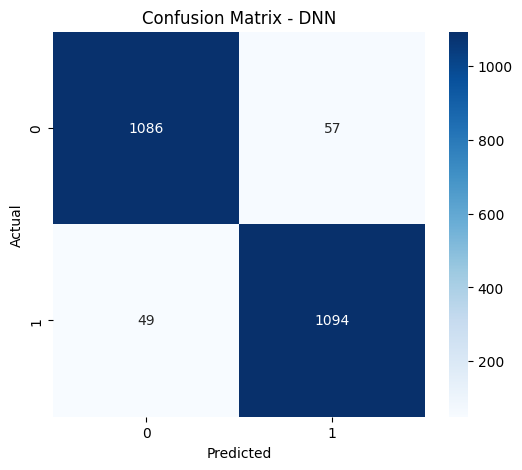

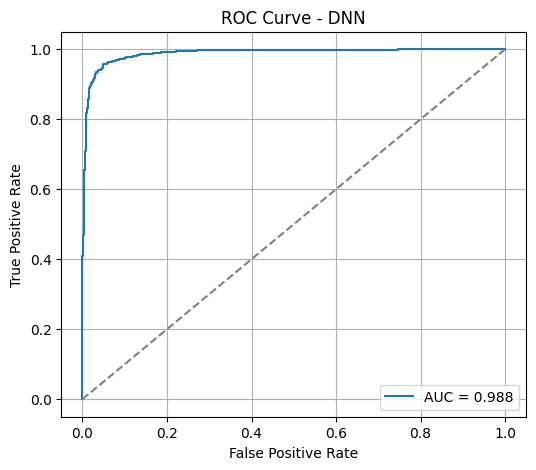

[FNN] Epoch  1 | Loss: 0.2705
[FNN] Epoch  2 | Loss: 0.1715
[FNN] Epoch  3 | Loss: 0.1609
[FNN] Epoch  4 | Loss: 0.1561
[FNN] Epoch  5 | Loss: 0.1503
[FNN] Epoch  6 | Loss: 0.1436
[FNN] Epoch  7 | Loss: 0.1395
[FNN] Epoch  8 | Loss: 0.1332
[FNN] Epoch  9 | Loss: 0.1322
[FNN] Epoch 10 | Loss: 0.1321
[FNN] Epoch 11 | Loss: 0.1309
[FNN] Epoch 12 | Loss: 0.1297
[FNN] Epoch 13 | Loss: 0.1255
[FNN] Epoch 14 | Loss: 0.1256
[FNN] Epoch 15 | Loss: 0.1232


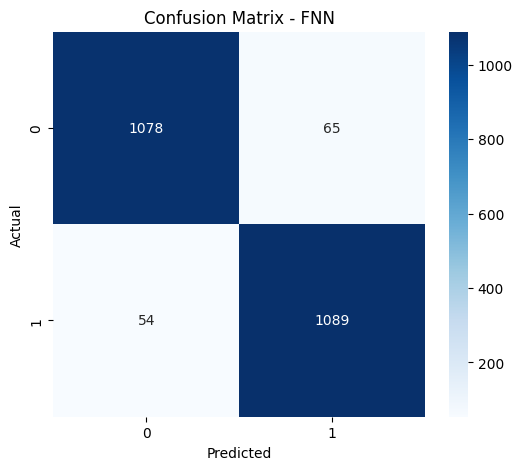

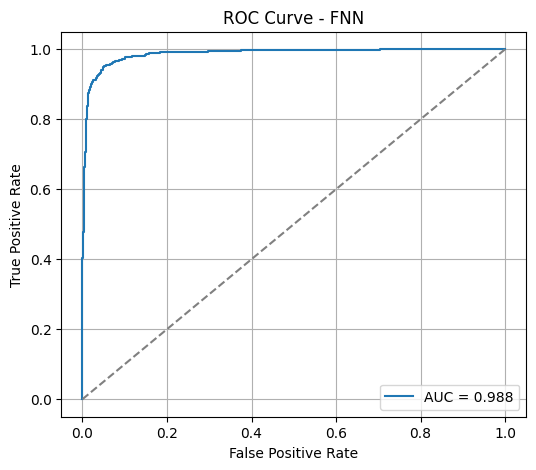

[AutoencoderClassifier] Epoch  1 | Loss: 0.3065
[AutoencoderClassifier] Epoch  2 | Loss: 0.1676
[AutoencoderClassifier] Epoch  3 | Loss: 0.1514
[AutoencoderClassifier] Epoch  4 | Loss: 0.1424
[AutoencoderClassifier] Epoch  5 | Loss: 0.1343
[AutoencoderClassifier] Epoch  6 | Loss: 0.1275
[AutoencoderClassifier] Epoch  7 | Loss: 0.1241
[AutoencoderClassifier] Epoch  8 | Loss: 0.1179
[AutoencoderClassifier] Epoch  9 | Loss: 0.1152
[AutoencoderClassifier] Epoch 10 | Loss: 0.1122
[AutoencoderClassifier] Epoch 11 | Loss: 0.1097
[AutoencoderClassifier] Epoch 12 | Loss: 0.1088
[AutoencoderClassifier] Epoch 13 | Loss: 0.1050
[AutoencoderClassifier] Epoch 14 | Loss: 0.1054
[AutoencoderClassifier] Epoch 15 | Loss: 0.1018


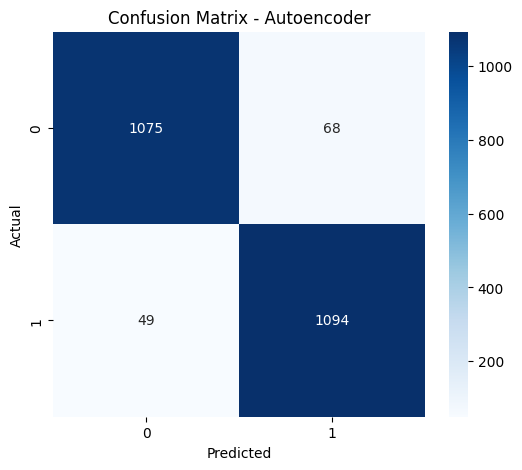

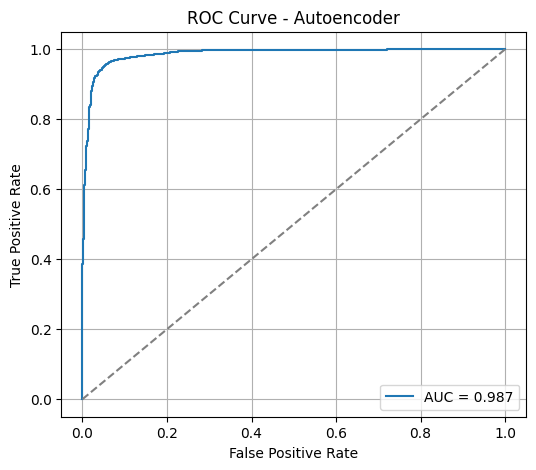


Training SAINT Model...
[SAINT] Epoch  1 | Loss: 0.3243
[SAINT] Epoch  2 | Loss: 0.1748
[SAINT] Epoch  3 | Loss: 0.1595
[SAINT] Epoch  4 | Loss: 0.1523
[SAINT] Epoch  5 | Loss: 0.1468
[SAINT] Epoch  6 | Loss: 0.1443
[SAINT] Epoch  7 | Loss: 0.1388
[SAINT] Epoch  8 | Loss: 0.1322
[SAINT] Epoch  9 | Loss: 0.1303
[SAINT] Epoch 10 | Loss: 0.1237
[SAINT] Epoch 11 | Loss: 0.1217
[SAINT] Epoch 12 | Loss: 0.1221
[SAINT] Epoch 13 | Loss: 0.1197
[SAINT] Epoch 14 | Loss: 0.1161
[SAINT] Epoch 15 | Loss: 0.1100
[SAINT] Epoch 16 | Loss: 0.1097
[SAINT] Epoch 17 | Loss: 0.1054
[SAINT] Epoch 18 | Loss: 0.1025
[SAINT] Epoch 19 | Loss: 0.1027
[SAINT] Epoch 20 | Loss: 0.0981


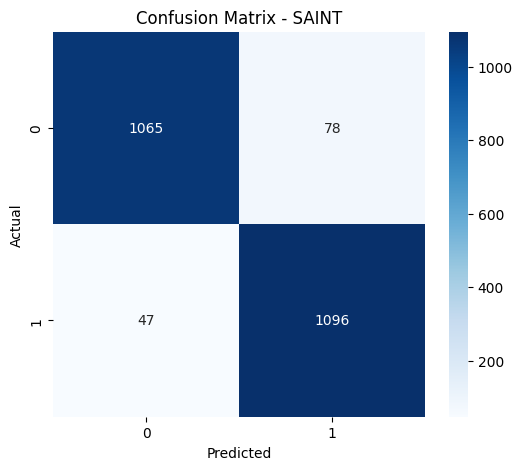

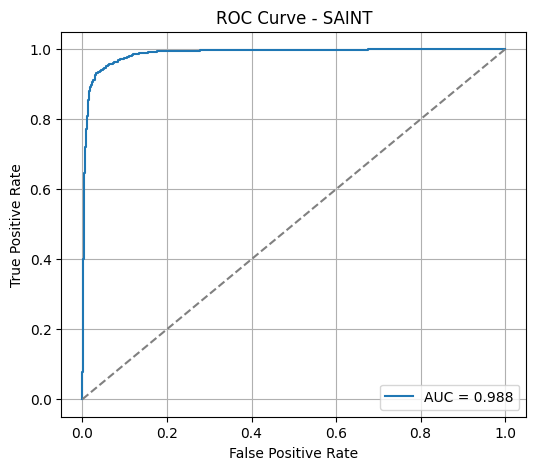


📊 Final Model Comparison (Sorted by AUC):

             Accuracy  Precision  Recall  F1 Score     AUC
DNN            0.9536     0.9505  0.9571    0.9538  0.9884
SAINT          0.9453     0.9336  0.9589    0.9461  0.9880
FNN            0.9479     0.9437  0.9528    0.9482  0.9876
NAS_Keras      0.9545     0.9482  0.9615    0.9548  0.9869
Autoencoder    0.9488     0.9415  0.9571    0.9492  0.9866


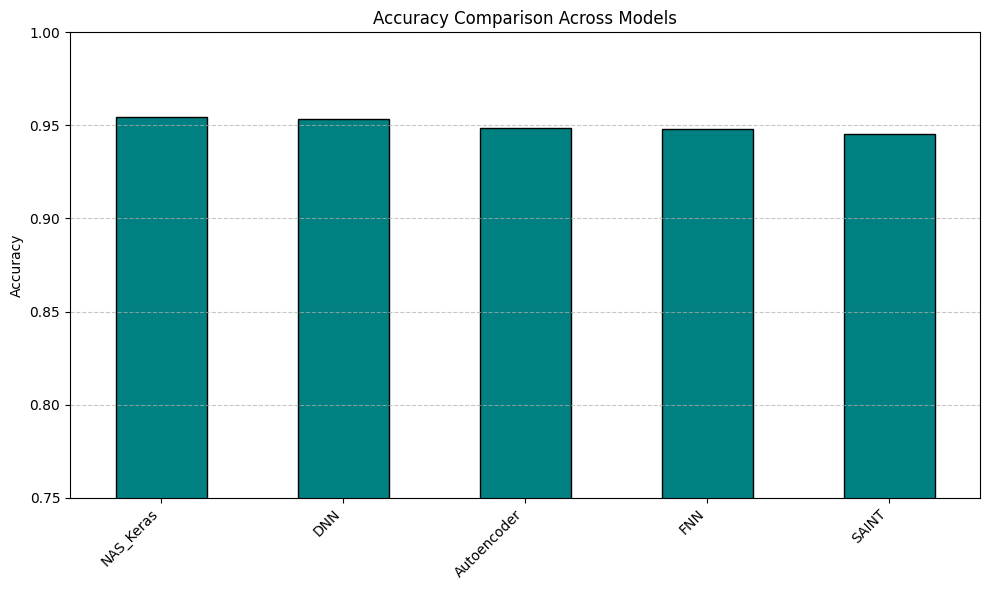

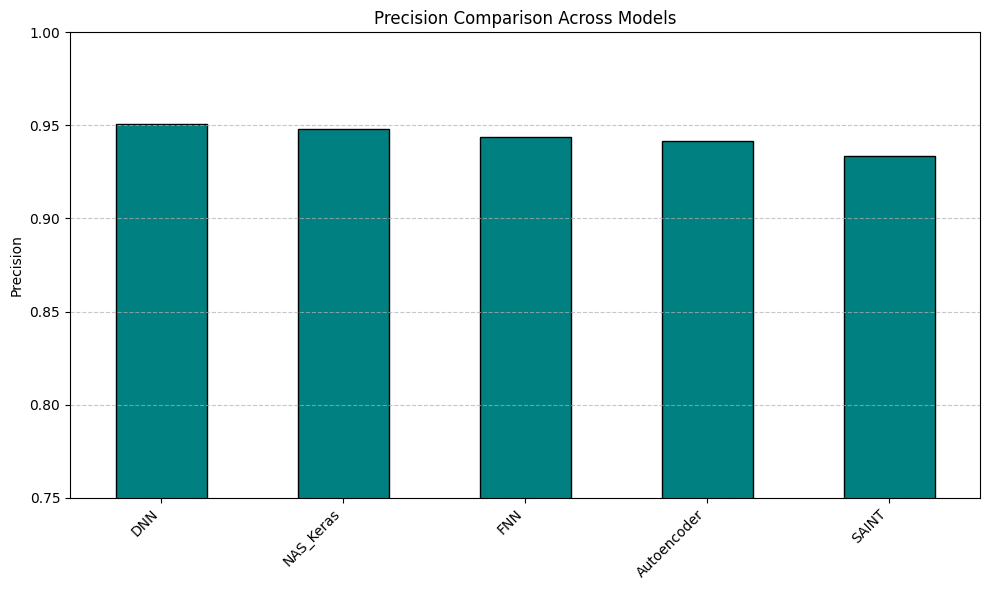

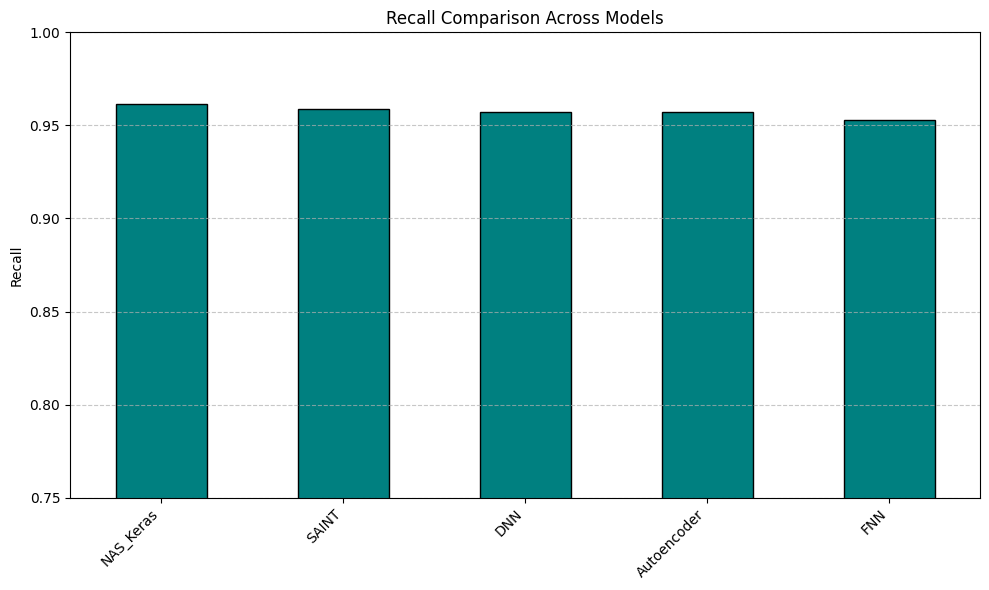

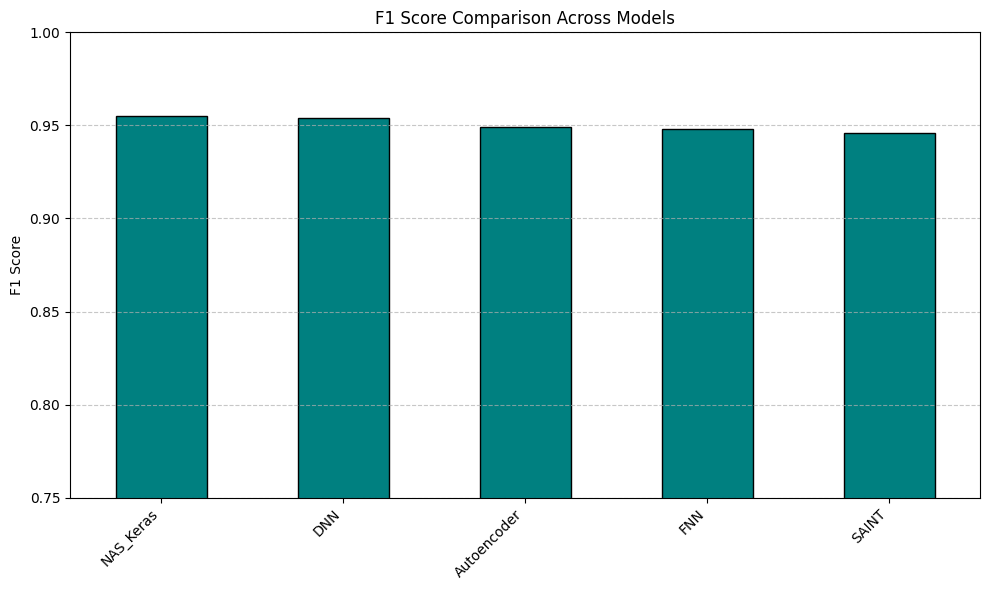

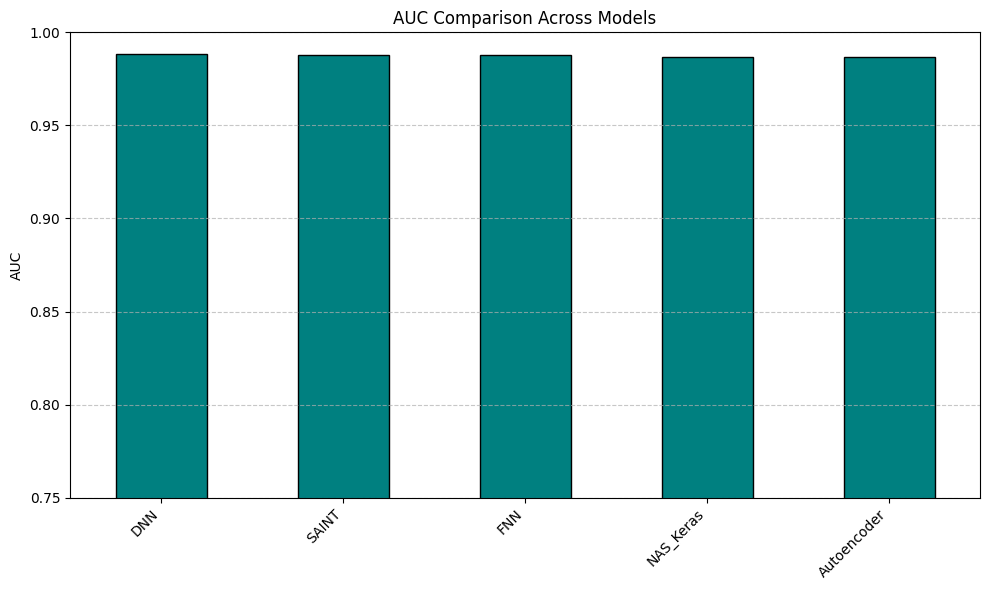

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ======= Data to Tensors =======
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)
y_train_tensor = torch.LongTensor(y_train.values)
y_test_tensor = torch.LongTensor(y_test.values)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ======= PyTorch Models =======

class DNN(nn.Module):
    def __init__(self, input_dim, units=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, units), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(units, units // 2), nn.ReLU(),
            nn.Linear(units // 2, 2)
        )
    def forward(self, x):
        return self.net(x)

class FNN(nn.Module):
    def __init__(self, input_dim, units=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, units), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(units, units // 2), nn.ReLU(),
            nn.Linear(units // 2, 2)
        )
    def forward(self, x):
        return self.net(x)

class AutoencoderClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, input_dim)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 2)
        )
    def forward(self, x):
        encoded = self.encoder(x)
        _ = self.decoder(encoded)
        return self.classifier(encoded)

# ======= Proper SAINT Implementation (Self-Attention and Intersample Attention Network) =======
class SAINT(nn.Module):
    def __init__(self, input_dim, dim=64, depth=4, heads=8, dim_head=32, dropout=0.1, num_classes=2):
        super().__init__()
        self.dim = dim
        
        # Project each feature independently to embedding dimension
        self.feature_proj = nn.Linear(1, dim)
        
        # [CLS] token for classification
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        
        # Positional embedding for features + CLS
        self.pos_emb = nn.Embedding(input_dim + 1, dim)  # +1 for CLS
        
        # Transformer blocks
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                # Column attention (self-attention over features)
                nn.MultiheadAttention(embed_dim=dim, num_heads=heads, dropout=dropout, batch_first=True),
                nn.LayerNorm(dim),
                # Row attention (intersample attention)
                nn.MultiheadAttention(embed_dim=dim, num_heads=heads, dropout=dropout, batch_first=True),
                nn.LayerNorm(dim),
                # Feed-forward
                nn.Linear(dim, dim * 4),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(dim * 4, dim),
                nn.LayerNorm(dim)
            ]))
        
        self.final_norm = nn.LayerNorm(dim)
        self.classifier = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(dim // 2, num_classes)
        )

    def forward(self, x):
        b, n = x.shape  # batch_size, num_features
        
        # Project each feature to dim
        x = x.unsqueeze(-1)                # (b, n, 1)
        x = self.feature_proj(x)           # (b, n, dim)
        
        # Add [CLS] token
        cls_tokens = self.cls_token.expand(b, -1, -1)  # (b, 1, dim)
        x = torch.cat((cls_tokens, x), dim=1)          # (b, n+1, dim)
        
        # Add positional embeddings
        positions = torch.arange(n + 1, device=x.device).unsqueeze(0).expand(b, -1)
        x = x + self.pos_emb(positions)
        
        # Transformer blocks
        for col_attn, col_norm, row_attn, row_norm, ff1, act, ff_drop, ff2, ff_norm in self.layers:
            # 1. Column attention (self-attention over features)
            attn_out, _ = col_attn(x, x, x)
            x = col_norm(x + attn_out)
            
            # 2. Row attention (intersample attention)
            x_t = x.permute(1, 0, 2)  # (n+1, b, dim)
            attn_out_t, _ = row_attn(x_t, x_t, x_t)
            x = row_norm(x + attn_out_t.permute(1, 0, 2))
            
            # 3. Feed-forward
            ff = ff2(ff_drop(act(ff1(x))))
            x = ff_norm(x + ff)
        
        x = self.final_norm(x)
        
        # Classification from [CLS] token
        cls_repr = x[:, 0]  # (b, dim)
        return self.classifier(cls_repr)

# ======= Helper Functions =======

def train_model(model, loader, epochs=15, lr=0.001):
    model.to(device)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = loss_fn(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        print(f"[{model.__class__.__name__}] Epoch {epoch+1:2d} | Loss: {avg_loss:.4f}")

def evaluate_model(model, loader, model_name="Model"):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            prob = torch.softmax(out, dim=1)[:, 1]
            pred = torch.argmax(out, dim=1)
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': auc_score
    }

# ======= Keras Tuner (Fixed & Safe) =======
def build_keras_model(hp):
    units = hp.Int('units', min_value=64, max_value=384, step=64)
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    
    model = Sequential()
    model.add(Dense(units=units, activation='relu', input_dim=X_train.shape[1]))
    model.add(Dropout(0.3))
    model.add(Dense(units=units // 2, activation='relu'))
    model.add(Dense(2, activation='softmax'))
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.Hyperband(
    build_keras_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='tuner_dir',
    project_name='phishing_detection',
    overwrite=True
)

print("Starting Hyperparameter Search...")
tuner.search(
    X_train.values, y_train.values,
    epochs=10,
    validation_data=(X_test.values, y_test.values),
    batch_size=64,
    verbose=1
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBest Hyperparameters: units={best_hps.get('units')}, lr={best_hps.get('learning_rate'):.2e}")

best_keras_model = build_keras_model(best_hps)
print("\nTraining Best Keras Model...")
best_keras_model.fit(
    X_train.values, y_train.values,
    validation_data=(X_test.values, y_test.values),
    epochs=20,
    batch_size=64,
    verbose=1
)

# Evaluate NAS model
keras_preds = (best_keras_model.predict(X_test.values)[:, 1] > 0.5).astype(int)
keras_probs = best_keras_model.predict(X_test.values)[:, 1]
nas_results = {
    'Accuracy': accuracy_score(y_test, keras_preds),
    'Precision': precision_score(y_test, keras_preds, zero_division=0),
    'Recall': recall_score(y_test, keras_preds, zero_division=0),
    'F1 Score': f1_score(y_test, keras_preds, zero_division=0),
    'AUC': roc_auc_score(y_test, keras_probs)
}

# ======= Train & Evaluate All Models =======
results = {}
results['NAS_Keras'] = nas_results

# DNN
dnn = DNN(X_train.shape[1]).to(device)
train_model(dnn, train_loader, epochs=15)
results['DNN'] = evaluate_model(dnn, test_loader, "DNN")

# FNN
fnn = FNN(X_train.shape[1]).to(device)
train_model(fnn, train_loader, epochs=15)
results['FNN'] = evaluate_model(fnn, test_loader, "FNN")

# Autoencoder Classifier
auto = AutoencoderClassifier(X_train.shape[1]).to(device)
train_model(auto, train_loader, epochs=15)
results['Autoencoder'] = evaluate_model(auto, test_loader, "Autoencoder")

# SAINT Model
saint = SAINT(
    input_dim=X_train.shape[1],
    dim=64,
    depth=4,
    heads=8,
    dim_head=32,
    dropout=0.1
).to(device)

print("\nTraining SAINT Model...")
train_model(saint, train_loader, epochs=20, lr=0.0005)  # Slightly lower LR recommended
results['SAINT'] = evaluate_model(saint, test_loader, "SAINT")

# ======= Final Comparison =======
results_df = pd.DataFrame(results).T.round(4)
print("\n📊 Final Model Comparison (Sorted by AUC):\n")
print(results_df.sort_values('AUC', ascending=False))

# ======= Bar Plots =======
for metric in results_df.columns:
    plt.figure(figsize=(10, 6))
    results_df[metric].sort_values(ascending=False).plot(
        kind='bar', color='teal', edgecolor='black'
    )
    plt.title(f'{metric} Comparison Across Models')
    plt.ylabel(metric)
    plt.ylim(0.75, 1.0)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Using device: cuda
Building k-NN graph (k=10) on 11430 samples...
Full adj: torch.Size([11430, 11430]), Train adj: torch.Size([9144, 9144]), Test adj: torch.Size([2286, 2286])

STARTING GRAPH CONVOLUTIONAL NETWORK (GCN) - FULL BATCH
[GCN] Epoch   1 | Loss: 12.2303
[GCN] Epoch  10 | Loss: 2.3411
[GCN] Epoch  20 | Loss: 1.0673
[GCN] Epoch  30 | Loss: 0.7360
[GCN] Epoch  40 | Loss: 0.4737
[GCN] Epoch  50 | Loss: 0.3478


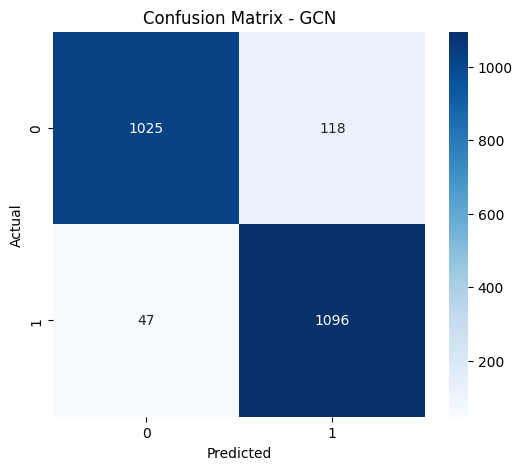

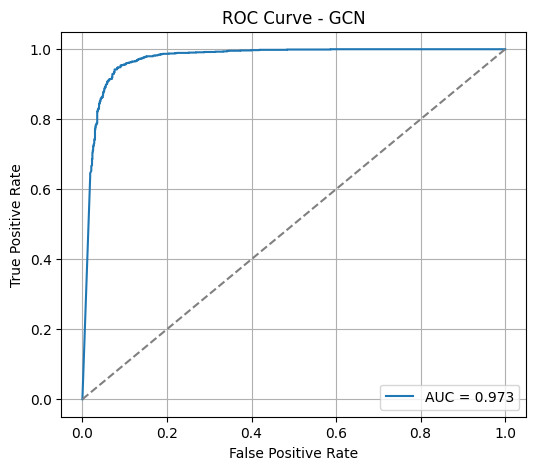


=== GCN Final Results ===
Accuracy: 0.9278
Precision: 0.9028
Recall: 0.9589
F1 Score: 0.9300
AUC: 0.9727


In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import kneighbors_graph

# ======= Data Preparation =======
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_np)
X_test_tensor = torch.FloatTensor(X_test_np)
y_train_tensor = torch.LongTensor(y_train_np)
y_test_tensor = torch.LongTensor(y_test_np)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ======= Build k-NN Adjacency Matrix (Global Graph) =======
def build_knn_adjacency(X, k=10):
    print(f"Building k-NN graph (k={k}) on {X.shape[0]} samples...")
    A = kneighbors_graph(X, n_neighbors=k, mode='connectivity', include_self=True)
    A = A.toarray()
    A = A + A.T  # Make symmetric
    A[A > 1] = 1  # Binarize
    return torch.FloatTensor(A)

# Combine train + test to build a global graph (best for transductive setting)
X_all = np.vstack([X_train_np, X_test_np])
adj_full = build_knn_adjacency(X_all, k=10).to(device)

n_train = X_train_tensor.shape[0]
n_test = X_test_tensor.shape[0]

# Split adjacency
adj_train = adj_full[:n_train, :n_train]           # Train-to-train
adj_test = adj_full[n_train:, n_train:]           # Test-to-test
adj_cross = adj_full[n_train:, :n_train]          # Test-to-train (important!)

print(f"Full adj: {adj_full.shape}, Train adj: {adj_train.shape}, Test adj: {adj_test.shape}")

# ======= GCN Model =======
class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
    
    def forward(self, x, adj):
        # x: (N, F), adj: (N, N)
        x = torch.mm(adj, x)       # Message passing
        x = self.linear(x)
        return x

class GCNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2, dropout=0.3):
        super().__init__()
        self.gcn1 = GCNLayer(input_dim, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, adj):
        x = F.relu(self.gcn1(x, adj))
        x = self.dropout(x)
        x = self.gcn2(x, adj)
        return x  # Raw logits

# ======= Full-Batch Training & Evaluation Functions =======
def train_gcn_fullbatch(model, X_train, y_train, adj_train, epochs=50, lr=0.01):
    model.to(device)
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    adj_train = adj_train.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    loss_fn = nn.CrossEntropyLoss()
    
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(X_train, adj_train)        # Full batch forward
        loss = loss_fn(out, y_train)
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[GCN] Epoch {epoch+1:3d} | Loss: {loss.item():.4f}")

def evaluate_gcn_fullbatch(model, X_train, X_test, y_test, adj_train, adj_cross, adj_test):
    model.eval()
    
    X_train = X_train.to(device)
    X_test = X_test.to(device)
    y_test = y_test.cpu().numpy()
    
    # Combine train + test nodes
    X_full = torch.cat([X_train, X_test], dim=0)
    
    # Full adjacency for forward pass
    adj_full_eval = torch.cat([
        torch.cat([adj_train, adj_cross.t()], dim=1),  # Train block
        torch.cat([adj_cross, adj_test], dim=1)       # Test block
    ], dim=0)
    
    with torch.no_grad():
        out_full = model(X_full, adj_full_eval)
        out_test = out_full[-X_test.shape[0]:]  # Only test nodes
        
        prob = torch.softmax(out_test, dim=1)[:, 1].cpu().numpy()
        pred = torch.argmax(out_test, dim=1).cpu().numpy()

    # Plots
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix - GCN")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
    plt.plot([0,1], [0,1], '--', color='gray')
    plt.title("ROC Curve - GCN")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()

    results = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1 Score': f1_score(y_test, pred, zero_division=0),
        'AUC': auc_score
    }
    
    print("\n=== GCN Final Results ===")
    for k, v in results.items():
        print(f"{k}: {v:.4f}")
    
    return results

# ======= Train and Evaluate GCN =======
print("\n" + "="*60)
print("STARTING GRAPH CONVOLUTIONAL NETWORK (GCN) - FULL BATCH")
print("="*60)

gcn_model = GCNClassifier(
    input_dim=X_train.shape[1],
    hidden_dim=64,
    output_dim=2,
    dropout=0.3
).to(device)

# Train on full training graph
train_gcn_fullbatch(
    gcn_model,
    X_train_tensor,
    y_train_tensor,
    adj_train,
    epochs=50,
    lr=0.01
)

# Evaluate with message passing from train → test nodes
gcn_results = evaluate_gcn_fullbatch(
    gcn_model,
    X_train_tensor,
    X_test_tensor,
    y_test_tensor,
    adj_train,
    adj_cross,
    adj_test
)

✅ NAS Keras model loaded successfully!

Making predictions on X_test...


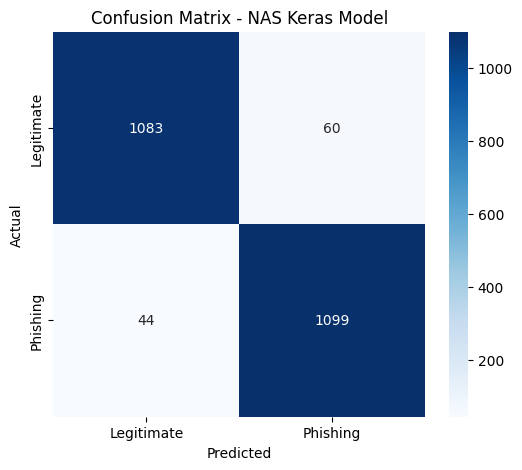


=== NAS Keras Model - Test Set Performance ===
Accuracy  : 0.9545
Precision : 0.9482
Recall    : 0.9615
F1 Score  : 0.9548
AUC       : 0.9869


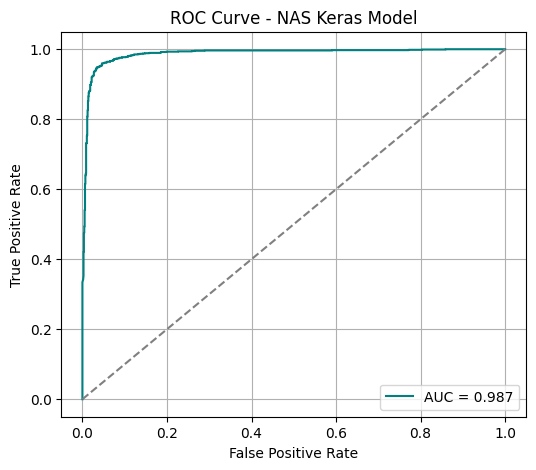

In [53]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# ======= 1. Load the saved NAS Keras model =======
model_path = "/kaggle/working/best_keras_model.h5"
nas_model = load_model(model_path)
print("✅ NAS Keras model loaded successfully!\n")

# ======= 2. Make predictions on the test set =======
print("Making predictions on X_test...")

# Get probabilities and predicted classes
test_probs = nas_model.predict(X_test.values, verbose=0)
test_pred_probs = test_probs[:, 1]                    # Probability of class 1 (Phishing)
test_preds = (test_pred_probs > 0.5).astype(int)      # Predictions with threshold 0.5

# True labels
y_true = y_test.values

# ======= 3. Compute and Plot Confusion Matrix =======
cm = confusion_matrix(y_true, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Phishing'], 
            yticklabels=['Legitimate', 'Phishing'])
plt.title("Confusion Matrix - NAS Keras Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ======= 4. Print Detailed Metrics =======
print("\n=== NAS Keras Model - Test Set Performance ===")
print(f"Accuracy  : {accuracy_score(y_true, test_preds):.4f}")
print(f"Precision : {precision_score(y_true, test_preds):.4f}")
print(f"Recall    : {recall_score(y_true, test_preds):.4f}")
print(f"F1 Score  : {f1_score(y_true, test_preds):.4f}")
print(f"AUC       : {roc_auc_score(y_true, test_pred_probs):.4f}")

# ======= 5. Optional: ROC Curve =======
fpr, tpr, _ = roc_curve(y_true, test_pred_probs)
auc_score = roc_auc_score(y_true, test_pred_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}', color='teal')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("ROC Curve - NAS Keras Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

Models will be saved in: /kaggle/working/
✅ NAS Keras model saved to: /kaggle/working/best_keras_model.h5
[DNN] Epoch  1 | Loss: 0.2635
[DNN] Epoch  2 | Loss: 0.1724
[DNN] Epoch  3 | Loss: 0.1572
[DNN] Epoch  4 | Loss: 0.1499
[DNN] Epoch  5 | Loss: 0.1415
[DNN] Epoch  6 | Loss: 0.1372
[DNN] Epoch  7 | Loss: 0.1366
[DNN] Epoch  8 | Loss: 0.1342
[DNN] Epoch  9 | Loss: 0.1294
[DNN] Epoch 10 | Loss: 0.1275
[DNN] Epoch 11 | Loss: 0.1244
[DNN] Epoch 12 | Loss: 0.1232
[DNN] Epoch 13 | Loss: 0.1208
[DNN] Epoch 14 | Loss: 0.1199
[DNN] Epoch 15 | Loss: 0.1182
✅ DNN model saved to: /kaggle/working/dnn_model.pth


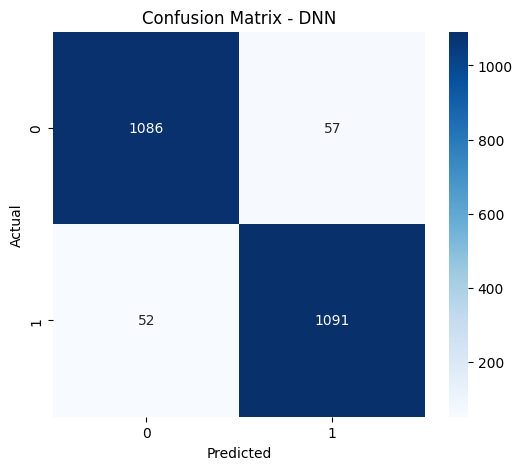

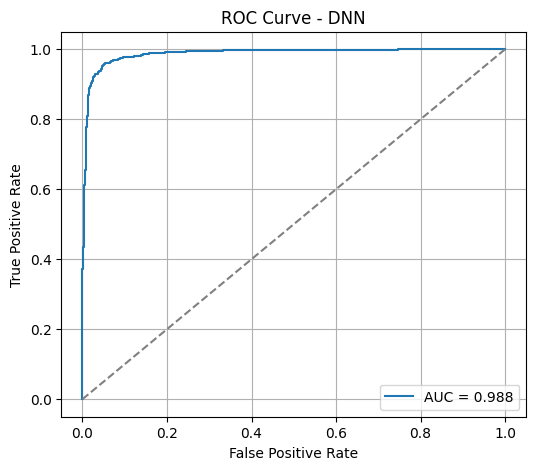

[FNN] Epoch  1 | Loss: 0.2617
[FNN] Epoch  2 | Loss: 0.1744
[FNN] Epoch  3 | Loss: 0.1609
[FNN] Epoch  4 | Loss: 0.1513
[FNN] Epoch  5 | Loss: 0.1436
[FNN] Epoch  6 | Loss: 0.1395
[FNN] Epoch  7 | Loss: 0.1386
[FNN] Epoch  8 | Loss: 0.1325
[FNN] Epoch  9 | Loss: 0.1357
[FNN] Epoch 10 | Loss: 0.1310
[FNN] Epoch 11 | Loss: 0.1257
[FNN] Epoch 12 | Loss: 0.1255
[FNN] Epoch 13 | Loss: 0.1213
[FNN] Epoch 14 | Loss: 0.1220
[FNN] Epoch 15 | Loss: 0.1187
✅ FNN model saved to: /kaggle/working/fnn_model.pth


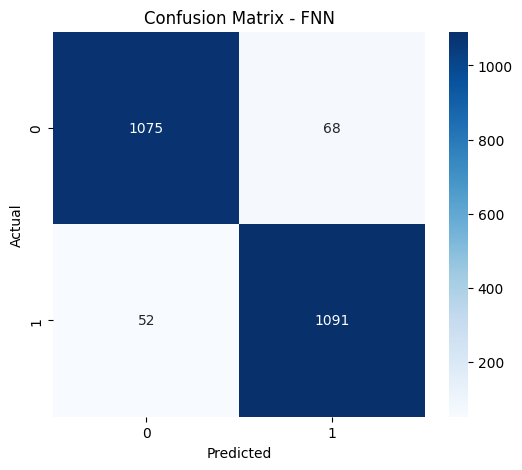

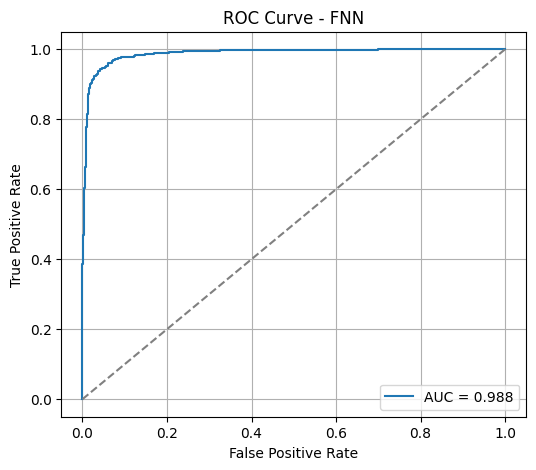

[AutoencoderClassifier] Epoch  1 | Loss: 0.3010
[AutoencoderClassifier] Epoch  2 | Loss: 0.1632
[AutoencoderClassifier] Epoch  3 | Loss: 0.1493
[AutoencoderClassifier] Epoch  4 | Loss: 0.1398
[AutoencoderClassifier] Epoch  5 | Loss: 0.1317
[AutoencoderClassifier] Epoch  6 | Loss: 0.1263
[AutoencoderClassifier] Epoch  7 | Loss: 0.1233
[AutoencoderClassifier] Epoch  8 | Loss: 0.1194
[AutoencoderClassifier] Epoch  9 | Loss: 0.1143
[AutoencoderClassifier] Epoch 10 | Loss: 0.1136
[AutoencoderClassifier] Epoch 11 | Loss: 0.1102
[AutoencoderClassifier] Epoch 12 | Loss: 0.1084
[AutoencoderClassifier] Epoch 13 | Loss: 0.1064
[AutoencoderClassifier] Epoch 14 | Loss: 0.1051
[AutoencoderClassifier] Epoch 15 | Loss: 0.1042
✅ Autoencoder model saved to: /kaggle/working/autoencoder_model.pth


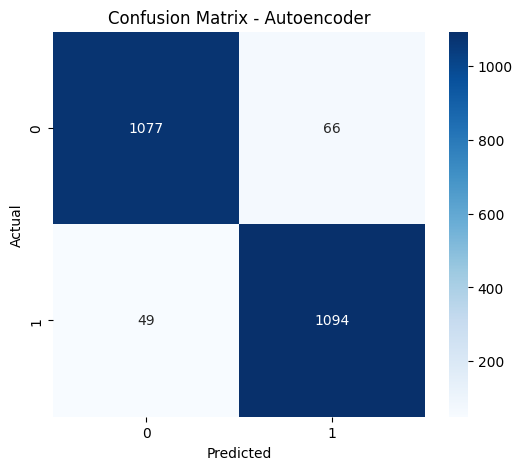

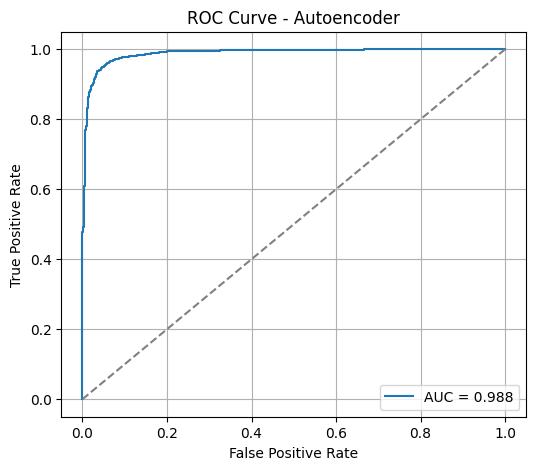


Training SAINT Model...
[SAINT] Epoch  1 | Loss: 0.2725
[SAINT] Epoch  2 | Loss: 0.1882
[SAINT] Epoch  3 | Loss: 0.1698
[SAINT] Epoch  4 | Loss: 0.1526
[SAINT] Epoch  5 | Loss: 0.1414
[SAINT] Epoch  6 | Loss: 0.1409
[SAINT] Epoch  7 | Loss: 0.1353
[SAINT] Epoch  8 | Loss: 0.1373
[SAINT] Epoch  9 | Loss: 0.1279
[SAINT] Epoch 10 | Loss: 0.1227
[SAINT] Epoch 11 | Loss: 0.1217
[SAINT] Epoch 12 | Loss: 0.1173
[SAINT] Epoch 13 | Loss: 0.1170
[SAINT] Epoch 14 | Loss: 0.1141
[SAINT] Epoch 15 | Loss: 0.1107
[SAINT] Epoch 16 | Loss: 0.1072
[SAINT] Epoch 17 | Loss: 0.1042
[SAINT] Epoch 18 | Loss: 0.1040
[SAINT] Epoch 19 | Loss: 0.1015
[SAINT] Epoch 20 | Loss: 0.1020
✅ SAINT model saved to: /kaggle/working/saint_model.pth


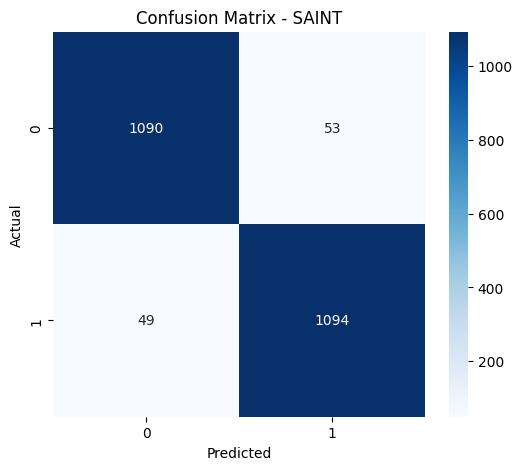

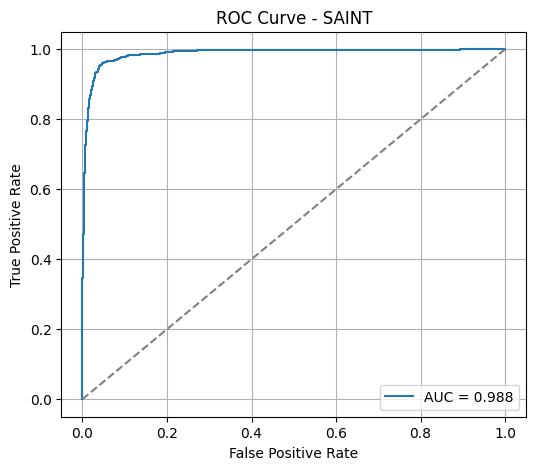

In [35]:
import os

# Create a directory to save all models
save_dir = "/kaggle/working/"
os.makedirs(save_dir, exist_ok=True)
print(f"Models will be saved in: {save_dir}")

# ======= Train & Evaluate All Models (WITH SAVING) =======
results = {}

# --- NAS Keras Model ---
# (already trained above)

keras_model_path = os.path.join(save_dir, "best_keras_model.h5")
best_keras_model.save(keras_model_path)
print(f"✅ NAS Keras model saved to: {keras_model_path}")

nas_results = {
    'Accuracy': accuracy_score(y_test, keras_preds),
    'Precision': precision_score(y_test, keras_preds, zero_division=0),
    'Recall': recall_score(y_test, keras_preds, zero_division=0),
    'F1 Score': f1_score(y_test, keras_preds, zero_division=0),
    'AUC': roc_auc_score(y_test, keras_probs)
}
results['NAS_Keras'] = nas_results

# --- DNN ---
dnn = DNN(X_train.shape[1]).to(device)
train_model(dnn, train_loader, epochs=15)

dnn_path = os.path.join(save_dir, "dnn_model.pth")
torch.save(dnn.state_dict(), dnn_path)
print(f"✅ DNN model saved to: {dnn_path}")

results['DNN'] = evaluate_model(dnn, test_loader, "DNN")

# --- FNN ---
fnn = FNN(X_train.shape[1]).to(device)
train_model(fnn, train_loader, epochs=15)

fnn_path = os.path.join(save_dir, "fnn_model.pth")
torch.save(fnn.state_dict(), fnn_path)
print(f"✅ FNN model saved to: {fnn_path}")

results['FNN'] = evaluate_model(fnn, test_loader, "FNN")

# --- Autoencoder Classifier ---
auto = AutoencoderClassifier(X_train.shape[1]).to(device)
train_model(auto, train_loader, epochs=15)

auto_path = os.path.join(save_dir, "autoencoder_model.pth")
torch.save(auto.state_dict(), auto_path)
print(f"✅ Autoencoder model saved to: {auto_path}")

results['Autoencoder'] = evaluate_model(auto, test_loader, "Autoencoder")

# --- SAINT Model ---
saint = SAINT(
    input_dim=X_train.shape[1],
    dim=64,
    depth=4,
    heads=8,
    dim_head=32,
    dropout=0.1
).to(device)

print("\nTraining SAINT Model...")
train_model(saint, train_loader, epochs=20, lr=0.0005)

saint_path = os.path.join(save_dir, "saint_model.pth")
torch.save(saint.state_dict(), saint_path)
print(f"✅ SAINT model saved to: {saint_path}")

results['SAINT'] = evaluate_model(saint, test_loader, "SAINT")

In [36]:
# Define feature columns
feature_columns = ['length_url', 'length_hostname', 'ip', 'nb_qm', 'nb_eq', 'nb_slash',
                   'nb_www', 'ratio_digits_url', 'ratio_digits_host', 'tld_in_subdomain',
                   'prefix_suffix', 'shortest_word_host', 'longest_word_path', 'phish_hints',
                   'nb_hyperlinks', 'ratio_intHyperlinks', 'domain_in_title', 'domain_age',
                   'google_index', 'page_rank']

# Create a list to store feature names with status 0
features_with_status_0 = []

# Loop through each feature and check its status
for feature in feature_columns:
    if df[feature].iloc[0] == 0:  # Assuming first row indicates the status (adjust accordingly)
        features_with_status_0.append(feature)

print(features_with_status_0)


['ip', 'nb_qm', 'nb_eq', 'ratio_digits_url', 'ratio_digits_host', 'tld_in_subdomain', 'prefix_suffix', 'phish_hints', 'domain_in_title']


In [37]:
df1 =pd.read_csv('/kaggle/input/phishingdata/dataset_B_05_2020 (1).csv')

In [43]:
import pandas as pd

# Set pandas display options to show the entire content (no truncation)
pd.set_option('display.max_colwidth', None)  # No truncation of URL or any column content
pd.set_option('display.max_rows', None)      # Show all rows if necessary
pd.set_option('display.max_columns', None)   # Show all columns if necessary

# Define feature columns
feature_columns = ['url', 'length_url', 'length_hostname', 'ip', 'nb_qm', 'nb_eq', 'nb_slash',
                   'nb_www', 'ratio_digits_url', 'ratio_digits_host', 'tld_in_subdomain',
                   'prefix_suffix', 'shortest_word_host', 'longest_word_path', 'phish_hints',
                   'nb_hyperlinks', 'ratio_intHyperlinks', 'domain_in_title', 'domain_age',
                   'google_index', 'page_rank']

# Filter the dataframe for rows where status is 'legitimate'
df_status_0 = df1[df1['status'] == "legitimate"]

# Get the first 5 rows for the specified feature columns, including the 'url'
df_status_0_first_5 = df_status_0[feature_columns].head(5)

# Print the first 5 rows, including the full URL and other feature values
print("Full URL and Other Feature Values for the first 5 legitimate rows:\n")
print(df_status_0_first_5)


Full URL and Other Feature Values for the first 5 legitimate rows:

                                                       url  length_url  \
0                    http://www.crestonwood.com/router.php          37   
3                                       http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorsports-park/          55   
6                                      http://www.mutuo.it          19   
8               http://vamoaestudiarmedicina.blogspot.com/          42   

   length_hostname  ip  nb_qm  nb_eq  nb_slash  nb_www  ratio_digits_url  \
0               19   0      0      0         3       1               0.0   
3               11   0      0      0         2       0               0.0   
4               15   0      0      0         5       1               0.0   
6               12   0      0      0         2       1               0.0   
8               34   0      0      0         3       0               0.0   

   ratio_digits_host  tld_in_s

In [46]:
import pandas as pd

# Set pandas display options to show the entire content (no truncation)
pd.set_option('display.max_colwidth', None)  # No truncation of URL or any column content
pd.set_option('display.max_rows', None)      # Show all rows if necessary
pd.set_option('display.max_columns', None)   # Show all columns if necessary

# Define feature columns
feature_columns = ['url', 'length_url', 'length_hostname', 'ip', 'nb_qm', 'nb_eq', 'nb_slash',
                   'nb_www', 'ratio_digits_url', 'ratio_digits_host', 'tld_in_subdomain',
                   'prefix_suffix', 'shortest_word_host', 'longest_word_path', 'phish_hints',
                   'nb_hyperlinks', 'ratio_intHyperlinks', 'domain_in_title', 'domain_age',
                   'google_index', 'page_rank']

# Filter the dataframe for rows where status is 'phishing'
df_status_0 = df1[df1['status'] == "phishing"]

# Get the first 5 rows for the specified feature columns, including the 'url'
df_status_0_first_5 = df_status_0[feature_columns].head(5)

# Print the first 5 rows, including the full URL and other feature values
print("Full URL and Other Feature Values for the first 5 legitimate rows:\n")
print(df_status_0_first_5)


Full URL and Other Feature Values for the first 5 legitimate rows:

                                                                                                                               url  \
1                                                    http://shadetreetechnology.com/V4/validation/a111aedc8ae390eabcfa130e041a10a4   
2   https://support-appleld.com.secureupdate.duilawyeryork.com/ap/89e6a3b4b063b8d/?cmd=_update&dispatch=89e6a3b4b063b8d1b&locale=_   
5                                                                                                 http://appleid.apple.com-app.es/   
7                                                http://www.shadetreetechnology.com/V4/validation/ba4b8bddd7958ecb8772c836c2969531   
13                                                                                                 http://html.house/l7ceeid6.html   

    length_url  length_hostname  ip  nb_qm  nb_eq  nb_slash  nb_www  \
1           77               23   1      0      0       

In [52]:
# ======= 3. Your specific 20-value input =======
your_input_values = [37, 19, 0, 0, 0, 3, 1, 0.0, 0.0, 0, 0, 3, 6, 0, 17, 0.529412, 0, -1, 1, 4]

# Create DataFrame with correct column order
input_df = pd.DataFrame([your_input_values], columns=selected_feature_names)

print("Your raw input:")
print(input_df.iloc[0].to_list())
print()

# ======= 4. Scale the input =======
scaled_input = scaler.transform(input_df)

# ======= 5. Predict with threshold = 0.5 =======
probs = nas_model.predict(scaled_input, verbose=0)
phishing_prob = probs[0][1]
legitimate_prob = probs[0][0]

# Strict 0.5 threshold
prediction = "Phishing" if phishing_prob > 0.5 else "Legitimate"

# ======= 6. Final Result (threshold 0.5 only) =======
print("="*60)
print("           PREDICTION RESULT (Threshold = 0.5)")
print("="*60)
print(f"Legitimate Probability : {legitimate_prob:.4f}")
print(f"Phishing Probability   : {phishing_prob:.4f}")
print(f"Final Prediction       : {prediction}")
print("="*60)

Your raw input:
[37.0, 19.0, 0.0, 0.0, 0.0, 3.0, 1.0, 0.0, 0.0, 0.0, 0.0, 3.0, 6.0, 0.0, 17.0, 0.529412, 0.0, -1.0, 1.0, 4.0]

           PREDICTION RESULT (Threshold = 0.5)
Legitimate Probability : 0.9210
Phishing Probability   : 0.0790
Final Prediction       : Legitimate


In [51]:
# ======= 3. Your specific 20-value input =======
your_input_values = [77, 23, 1, 0, 0, 5, 0, 0.220779, 0.0, 0,
                     0, 19, 32, 0, 30, 0.966667, 1, 5767, 1, 2]

# Create DataFrame with correct column order
input_df = pd.DataFrame([your_input_values], columns=selected_feature_names)

print("Your raw input:")
print(input_df.iloc[0].to_list())
print()

# ======= 4. Scale the input =======
scaled_input = scaler.transform(input_df)

# ======= 5. Predict with threshold = 0.5 =======
probs = nas_model.predict(scaled_input, verbose=0)
phishing_prob = probs[0][1]
legitimate_prob = probs[0][0]

# Strict 0.5 threshold
prediction = "Phishing" if phishing_prob > 0.5 else "Legitimate"

# ======= 6. Final Result (threshold 0.5 only) =======
print("="*60)
print("           PREDICTION RESULT (Threshold = 0.5)")
print("="*60)
print(f"Legitimate Probability : {legitimate_prob:.4f}")
print(f"Phishing Probability   : {phishing_prob:.4f}")
print(f"Final Prediction       : {prediction}")
print("="*60)

Your raw input:
[77.0, 23.0, 1.0, 0.0, 0.0, 5.0, 0.0, 0.220779, 0.0, 0.0, 0.0, 19.0, 32.0, 0.0, 30.0, 0.966667, 1.0, 5767.0, 1.0, 2.0]

           PREDICTION RESULT (Threshold = 0.5)
Legitimate Probability : 0.0001
Phishing Probability   : 0.9999
Final Prediction       : Phishing
